# 01 - Baseline CNN Training

Trains the **Baseline CNN** on the original (un-augmented) dataset.

**Split strategy:** The labelled `train.csv` is split 80/20 (train/val). The Kaggle `test/` folder is unlabelled — Section 7 generates the submission file for the leaderboard.

## 1. Setup & Imports

In [1]:
import os, sys, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data

from sklearn.metrics import accuracy_score, f1_score, classification_report
import kagglehub

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

if torch.cuda.is_available():            device = torch.device('cuda')
elif torch.backends.mps.is_available(): device = torch.device('mps')
else:                                    device = torch.device('cpu')
print('Device:', device)

NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
for c in [os.path.join(NOTEBOOK_DIR,'../src'), os.path.join(NOTEBOOK_DIR,'src'),
          '/Applications/Universidade/4ano_2semestre/ACA/projeto2/aml-butterfly-generative-augmentation/src']:
    c = os.path.abspath(c)
    if os.path.isdir(c) and c not in sys.path:
        sys.path.append(c); break

from dataset import ButterflyDataset
from transforms import get_transforms
from models import BaselineCNN
from utils import get_splits, get_class_mapping, GLOBAL_SEED
print('Modules imported!')

/Users/ritapduarte/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Device: mps
Modules imported!


## 2. Load Dataset & Create 80/20 Split

In [2]:
path = kagglehub.competition_download('aca-tp-2')
train_dir = os.path.join(path, 'train')
test_dir  = os.path.join(path, 'test')   # unlabelled

df = pd.read_csv(os.path.join(path, 'train.csv'))[['filename', 'label']]

train_df, val_df = get_splits(df, seed=GLOBAL_SEED)
class_to_idx, idx_to_class, classes = get_class_mapping(df)
NUM_CLASSES = len(classes)

total = len(df)
print(f'Total      : {total}')
print(f'Train      : {len(train_df)}  ({len(train_df)/total*100:.1f}%)')
print(f'Validation : {len(val_df)}   ({len(val_df)/total*100:.1f}%)')
print(f'Classes    : {NUM_CLASSES}')

Total      : 5199
Train      : 4159  (80.0%)
Validation : 1040   (20.0%)
Classes    : 75


## 3. DataLoaders

In [3]:
BATCH_SIZE = 32
train_transform, val_transform = get_transforms()

train_dataset = ButterflyDataset(df=train_df, img_dir=train_dir, transform=train_transform)
val_dataset   = ButterflyDataset(df=val_df,   img_dir=train_dir, transform=val_transform)

train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = data.DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train batches: 130 | Val batches: 33


## 4. Model, Loss, Optimizer

In [4]:
model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

## 5. Training Loop with Early Stopping

In [5]:
EPOCHS = 150
PATIENCE = 15
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'val_f1':[]}

best_val_f1 = 0.0
epochs_without_improvement = 0
best_model_path = '../outputs/models/baseline_cnn_best.pth'
os.makedirs('../outputs/models', exist_ok=True)

for epoch in range(EPOCHS):
    model.train()
    trn_loss, preds_all, labels_all = 0.0, [], []
    for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs); loss = criterion(out, labels)
        loss.backward(); optimizer.step()
        trn_loss += loss.item() * imgs.size(0)
        preds_all.extend(out.argmax(1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    trn_loss /= len(train_dataset)
    trn_acc   = accuracy_score(labels_all, preds_all)

    model.eval()
    val_loss, preds_all, labels_all = 0.0, [], []
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Val]', leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            val_loss += criterion(out, labels).item() * imgs.size(0)
            preds_all.extend(out.argmax(1).cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    val_loss /= len(val_dataset)
    val_acc   = accuracy_score(labels_all, preds_all)
    val_f1    = f1_score(labels_all, preds_all, average='weighted')

    history['train_loss'].append(trn_loss)
    history['train_acc'].append(trn_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f'Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {trn_loss:.4f}  Acc: {trn_acc:.4f} '
          f'|| Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}  F1: {val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        epochs_without_improvement = 0
        torch.save(model.state_dict(), best_model_path)
        print(f' Best model saved (Val F1: {best_val_f1:.4f})')
    else:
        epochs_without_improvement += 1
        print(f'   No improvement for {epochs_without_improvement} epoch(s).')
        if epochs_without_improvement >= PATIENCE:
            print(f'\nEarly stopping triggered after {epoch+1} epochs! Model hasn\'t improved for {PATIENCE} epochs.')
            break

print('\nTraining complete!')

Epoch 1/80 [Train]:   0%|          | 0/130 [00:00<?, ?it/s]

Epoch 1/80 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 01/80 | Train Loss: 4.2084  Acc: 0.0224 || Val Loss: 3.9791  Acc: 0.0346  F1: 0.0041
 Best model saved (Val F1: 0.0041)


Epoch 2/80 [Train]:   0%|          | 0/130 [00:00<?, ?it/s]

Epoch 2/80 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

...

Epoch 27/80 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 27/80 | Train Loss: 2.2011  Acc: 0.3458 || Val Loss: 1.9066  Acc: 0.4298  F1: 0.4057
   No improvement for 4 epoch(s).


Epoch 28/80 [Train]:   0%|          | 0/130 [00:00<?, ?it/s]

Epoch 28/80 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 28/80 | Train Loss: 2.1292  Acc: 0.3655 || Val Loss: 1.8294  Acc: 0.4385  F1: 0.4116
   No improvement for 5 epoch(s).

Early stopping triggered after 28 epochs! Model hasn't improved for 5 epochs.

Training complete!


## 6. Learning Curves

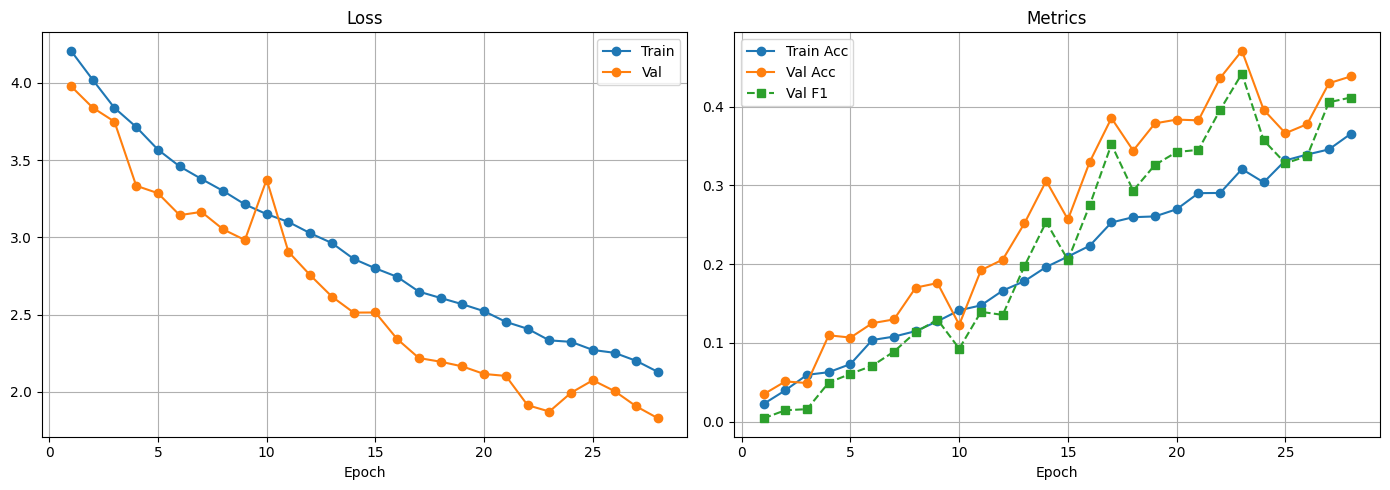

In [6]:
e = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(e, history['train_loss'], label='Train', marker='o')
axes[0].plot(e, history['val_loss'],   label='Val',   marker='o')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(e, history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(e, history['val_acc'],   label='Val Acc',   marker='o')
axes[1].plot(e, history['val_f1'],    label='Val F1',    marker='s', linestyle='--')
axes[1].set_title('Metrics'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True)

os.makedirs('../outputs', exist_ok=True)
plt.tight_layout()
plt.savefig('../outputs/baseline_learning_curves.png', dpi=150)
plt.show()

## 7. Per-class Validation Analysis

In [7]:
# Reload best model and evaluate on validation set
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

preds_all, labels_all = [], []
with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc='Val Evaluation'):
        preds_all.extend(model(imgs.to(device)).argmax(1).cpu().numpy())
        labels_all.extend(labels.numpy())

val_acc_final = accuracy_score(labels_all, preds_all)
val_f1_final  = f1_score(labels_all, preds_all, average='weighted')

print('=' * 50)
print('BASELINE CNN - BEST MODEL - VALIDATION RESULTS')
print('=' * 50)
print(f'Val Accuracy : {val_acc_final:.4f}')
print(f'Val F1-Score : {val_f1_final:.4f}  (weighted)')
print('=' * 50)

# Save for comparison with augmented models
with open('../outputs/baseline_results.json', 'w') as f:
    json.dump({'model': 'Baseline CNN', 'val_accuracy': val_acc_final,
               'val_f1_weighted': val_f1_final}, f, indent=2)
print('Saved to ../outputs/baseline_results.json')

report_df = pd.DataFrame(classification_report(
    labels_all, preds_all, target_names=train_dataset.classes, output_dict=True
)).T.dropna()

print('\n10 hardest classes:')
display(report_df.sort_values('f1-score').head(10)[['f1-score', 'support']])

Val Evaluation:   0%|          | 0/33 [00:00<?, ?it/s]

BASELINE CNN - BEST MODEL - VALIDATION RESULTS
Val Accuracy : 0.4712
Val F1-Score : 0.4420  (weighted)
Saved to ../outputs/baseline_results.json

10 hardest classes:


/Users/ritapduarte/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/ritapduarte/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/ritapduarte/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(resu

,f1-score,support
LARGE MARBLE,0.000000,13.0
METALMARK,0.000000,12.0
BLUE MORPHO,0.000000,12.0
SOUTHERN DOGFACE,0.000000,14.0
TROPICAL LEAFWING,0.000000,13.0
GREAT EGGFLY,0.000000,12.0
BLUE SPOTTED CROW,0.090909,14.0
MESTRA,0.111111,14.0
COPPER TAIL,0.117647,15.0
DANAID EGGFLY,0.125000,15.0


## 8. Generate Kaggle Submission File

Runs the best model on the unlabelled `test/` folder and saves `submission.csv` for the Kaggle leaderboard.

In [8]:
import torchvision.transforms as T
from PIL import Image

# List all test images
test_files = sorted(os.listdir(test_dir))
print(f'Test images: {len(test_files)}')

# Same transform as validation (no augmentation)
_, val_transform = get_transforms()

model.eval()
predictions = []

with torch.no_grad():
    for fname in tqdm(test_files, desc='Predicting test set'):
        img_path = os.path.join(test_dir, fname)
        img = Image.open(img_path).convert('RGB')
        img_tensor = val_transform(img).unsqueeze(0).to(device)
        pred_idx = model(img_tensor).argmax(1).item()
        pred_label = idx_to_class[pred_idx]
        predictions.append({'filename': fname, 'label': pred_label})

submission_df = pd.DataFrame(predictions)
submission_df.to_csv('../outputs/baseline_submission.csv', index=False)
print('Submission saved to ../outputs/baseline_submission.csv')
display(submission_df.head())

Test images: 1300


Predicting test set:   0%|          | 0/1300 [00:00<?, ?it/s]

Submission saved to ../outputs/baseline_submission.csv


,filename,label
0,Image_0.jpg,RED ADMIRAL
1,Image_1.jpg,APPOLLO
2,Image_10.jpg,ATALA
3,Image_100.jpg,RED SPOTTED PURPLE
4,Image_1000.jpg,YELLOW SWALLOW TAIL
